In [1]:
# import packages
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from freqit.oneway import freqtable
import textwrap

pd.set_option('display.max_colwidth', None)   # or use -1 for very old pandas
pd.set_option('display.max_rows', 200)   

# colors from d65 website and powerpoints:
d65_dark_blue = '#0F4C75'
d65_med_blue = '#1E7FBD'
d65_green = '#A8D5A3'
d65_light_gray = '#DCDCDC'
d65_dark_gray = '#6B8A99'

# Complementary additions:
d65_warm_coral = '#E07A5F'      # Warm coral/terracotta - complements the blues
d65_golden_yellow = '#F4A261'   # Soft golden yellow - adds warmth and energy
d65_cream = '#F8F5F2'           # Warm off-white - softer alternative to pure white
d65_navy = '#1A3A52'            # Deep navy - darker anchor color
d65_mint = '#C8E6C9'            # Light mint - harmonizes with your sage green
d65_rust = '#B85C50'            # Muted rust - deeper warm accent

node_colors = [d65_dark_blue, d65_rust,d65_green,d65_light_gray]

# Get Data

In [2]:
# raw_survey = pd.read_csv('../data_secret/Kingsley Closure Survey_20260117_932am.csv')
raw_survey = pd.read_csv('../data_secret/Kingsley Closure Survey_20260119_1746.csv')
print(f"Raw survey df shape: {raw_survey.shape}")
#raw_survey.columns

Raw survey df shape: (121, 21)


In [3]:
dup_emails = raw_survey[raw_survey['Username'].duplicated()].shape[0]
print(f"Email duplicates: {dup_emails}")

Email duplicates: 0


In [4]:
no_consent = raw_survey[raw_survey['I have read the above information and agree to participate in this survey.'] != 'Yes'].shape[0]
print(f"No consent: {no_consent}")

No consent: 1


# Clean

In [5]:
# rename columns
rename_cols_dict = {
    'Timestamp': 'timestamp',
    'Username': 'username',
    'I have read the above information and agree to participate in this survey.': 'consent',
    'Which school would your household be assigned to for the 2026–27 school year under the proposed boundaries?': 'assigned_school',
    'Which District 65 school would you prefer your child attend for the 2026–27 school year?': 'preferred_school',
    'What is most important to you when considering Kingsley attendance boundaries? Select up to two.': 'important_boundary_factors',
    'One transition approach under consideration would aim to balance walkability and community continuity by:\nMaintaining walkable attendance boundaries, and\nOffering guaranteed placement at a designated Kingsley receiving school for current Kingsley students who request it, without requiring permissive transfers.\nHow supportive are you of this approach?': 'support_walkability_community_continuity',
    'One transition approach under consideration would aim to balance walkability and community continuity by:\n- Maintaining walkable attendance boundaries, and\n- Offering guaranteed placement at a designated Kingsley receiving school for current Kingsley students who request it, without requiring permissive transfers.\nIf parent groups advocated for this option, at which school would you prefer to keep the community together?\nFor context: Lincolnwood has been discussed as a potential receiving school due to its proximity to Kingsley and central location. All schools are listed to understand family preferences assuming adequate capacity.': 'preferred_school_community_continuity',
    'If guaranteed placement were offered for current Kingsley students, which receiving school would you prefer?\n"Guaranteed placement" means the district commits in advance to enrolling a student at a specific school.\n': 'preferred_school_guaranteed_placement',
    'If the district proceeds with the proposed boundaries, would you request a permissive transfer to your preferred school?\n"Permissive transfer" means a family applies to attend a non-assigned school, subject to space availability. Permissive transfer approvals may arrive as late as 1-2 days before the school year begins.\n': 'request_permissive_transfer',
    'Which of the following would help your family feel more welcomed at your new school? Select all that apply.\n': 'help_feel_welcomed',
    'What traditions, programs, or aspects of Kingsley’s culture do you hope will continue in your child’s new school?': 'kingsley_culture_to_continue',
    'What support will your child or family need most during this transition?': 'needed_support_during_transition',
    'What are you most worried about regarding your school transition?': 'worries_about_transition',
    'What questions remain unanswered that you would like the Board or administration to address?': 'unanswered_questions',
    'How likely is it that your child(ren) will remain in District 65 for the 2026–27 school year?': 'likely_remain_district65',
    'If not District 65, where are your children most likely to attend school in 2026–27?': 'where_attend_not_district65',
    'If you were to leave District 65, which factors would contribute to that decision? Select all that apply.\n': 'factors_contribute_leave_district65',
    'Are you:': 'parent_type',
    'What grade(s) are your children currently in (2025–26 school year)? Select all that apply.\n': 'children_grades',
    'Anything else?\nPlease provide any other commentary or feedback on the SDRP process that you would like the Board of Education, district administration, Invest in Neighborhood Schools (IINS), or Legion of Data Nerds to consider.': 'additional_comments'
}

survey_df = raw_survey.rename(columns=rename_cols_dict)
survey_df = survey_df.drop(columns=['timestamp', 'username'])

survey_df = survey_df[survey_df['consent'] == 'Yes'].copy()
print(f"Survey df shape: {survey_df.shape}")
print(survey_df.columns)



Survey df shape: (120, 19)
Index(['consent', 'assigned_school', 'preferred_school',
       'important_boundary_factors',
       'support_walkability_community_continuity',
       'preferred_school_community_continuity',
       'preferred_school_guaranteed_placement', 'request_permissive_transfer',
       'help_feel_welcomed', 'kingsley_culture_to_continue',
       'needed_support_during_transition', 'worries_about_transition',
       'unanswered_questions', 'likely_remain_district65',
       'where_attend_not_district65', 'factors_contribute_leave_district65',
       'parent_type', 'children_grades', 'additional_comments'],
      dtype='object')


## Recode Values

In [6]:
# recode other specify
recode_dict_preferred_school = {
    'Lincolnwood': 'Lincolnwood ',
    'Willard': 'Willard ',
    'Orrington': 'Orrington ',
    'Foster': 'Foster ',
    'Not certain; preference would be the school with highest percentage of Kingsley students.': 'Most Kingsley Students',
    'Unsure': 'Don\'t Know',
    'unsure': 'Don\'t Know',
    'Don\'t Know': 'Don\'t Know',
    'Haven aging out': 'No Response',
    'I don\'t know - New to the district': 'Don\'t Know',
    'Lincoln wood or Willard': 'Lincolnwood or Willard',
    'Depends. I want the choice depending on where most of our community and friends will be going to, which is likely Lincolnwood': 'Most Kingsley Students',
    'Would rather have a choice for a permissive transfer depending upon where my son’s friends wind up': 'Most Kingsley Students',
    'No real preference': 'No Preference'
}
# recode specific columns only
survey_df['preferred_school'] = survey_df['preferred_school'].str.strip().replace(recode_dict_preferred_school)
survey_df['preferred_school'] = survey_df['preferred_school'].fillna('No Response')

recode_dict_boundary_factors = {
    'not having to move schools again if you close another next year': 'Students not placed at a school that may close',
    'That students are not placed at a school that might also close in the future': 'Students not placed at a school that may close',
    'Do not want children to be displaced twice, in likely event of Lincolnwood closure': 'Students not placed at a school that may close',
    'keeping the student/teacher ratio low in all schools': 'Low Student/Teacher Ratio',
    'Logical future boundaries, not short term considerations': 'Walkability, safety, and ease of access to school'
}

recode_dict_help_feel_welcomed = {
    'Field trips to receiving school(s) during school hours so students have dedicated time to interact with new peers':'Student classroom visits prior to the first day of school'
}

recode_dict_where_attend_not_district65 = {
    'Public school in Chicago due to parents in different locations': 'Chicago Public Schools',
    'May move back to the city, CPS is strangely looking more solid than D65!': 'Chicago Public Schools',
    'Unsure neurodivergent child': 'Don\'t Know',
    'No idea. Never wanted to have to make this choice —\xa0this is why we moved here in the first place': 'Don\'t Know',
    'Unknown ': 'Don\'t Know',
    "N/A-we're staying in D65": 'Stay in District 65',
    "We're not going anywhere": 'Stay in District 65',
    "Our eldest is at Haven and our youngest has already transitioned to St A's": 'Private school in Evanston',
}

recode_dict_factors_contribute_leave_district65 = {
    'too much trchnology': 'Too much technology',
    'We are not in a financial position to leave, and also strongly believe in public education, but if we were to ever leave it would be due to our disgust at the action/inaction of 3 board members (Mya, Sergio, Andrew) and our dissatisfaction with Superintendent Turner and her poor attitude.': 'Dissatisfaction with specific board members Mya Wilkins, Sergio Hernandez, Dr. Andrew Wymer;Dissatisfaction with Superintendent Dr. Angel Turner',
    'No personalized education or advanced curriculum': 'No advanced curriculum',
    'No advanced curriculum and too much reliance on personal devices in k-5': 'No advanced curriculum;Too much technology',
    'I feel strongly we need a complete overhaul of the school Administration. Our teachers are amazing. Very disappointed in leadership.': 'Lack of trust in district administration',
    'Dr. turners contract is renewed.': 'Dissatisfaction with Superintendent Dr. Angel Turner',
    "As a district we hold our students to such a low academic standard that kids aren’t required or expected to meet their potential": "District has not met my child’s academic, social, or emotional needs"
}

def recode_values(df, column_name, recode_dict):
    df[column_name] = df[column_name].str.strip()

    for key, value in recode_dict.items():
        df[column_name] = df[column_name].str.replace(key, value, regex=False)
        df[column_name] = df[column_name].str.replace("; ",";").str.replace(" ;",";")  # clean up any extra spaces around semicolons
        # df[column_name] = df[column_name].str.strip()
    
    df[column_name] = df[column_name].fillna('No Response')

recode_values(survey_df, 'important_boundary_factors', recode_dict_boundary_factors)
recode_values(survey_df, 'help_feel_welcomed', recode_dict_help_feel_welcomed)
recode_values(survey_df, 'where_attend_not_district65', recode_dict_where_attend_not_district65)
recode_values(survey_df, 'factors_contribute_leave_district65', recode_dict_factors_contribute_leave_district65)


In [7]:
survey_df['assigned_same_preferred'] = 0
survey_df.loc[survey_df['assigned_school'] == survey_df['preferred_school'].str.strip(), 'assigned_same_preferred'] = 1

survey_df['assigned_to_preferred'] = survey_df['assigned_school'] + ' - ' + survey_df['preferred_school']


## Recode multi select for charting

In [8]:
select_multi_cols = [
    'important_boundary_factors',
    'help_feel_welcomed',
    'factors_contribute_leave_district65',
    'children_grades'
]   

for col in select_multi_cols:
    print(f"Processing column: {col}")

    # recode multi select into new columns
    # survey_df[col] = survey_df[col].fillna('')
    survey_df.columns = survey_df.columns.str.strip()
    new_cols = survey_df[col].str.get_dummies(sep=';').add_prefix(f'{col}_')

    # combine the original DataFrame with the new columns
    survey_df = pd.concat([survey_df, new_cols], axis=1)

    # check new columns
    prefix = col 
    cols_starting_with = [c for c in survey_df.columns if c.startswith(prefix)]
    print(f"Columns for {col}: {cols_starting_with}")
    # display(survey_df[cols_starting_with].head())


Processing column: important_boundary_factors
Columns for important_boundary_factors: ['important_boundary_factors', 'important_boundary_factors_Diversity of student body', 'important_boundary_factors_Even distribution of students across schools', 'important_boundary_factors_Flexibility for families to choose the school that works best for them', 'important_boundary_factors_Low Student/Teacher Ratio', 'important_boundary_factors_Maximizing the number of Kingsley students who remain together', 'important_boundary_factors_Students not placed at a school that may close', 'important_boundary_factors_Walkability, safety, and ease of access to school']
Processing column: help_feel_welcomed
Columns for help_feel_welcomed: ['help_feel_welcomed', 'help_feel_welcomed_504 Plan / IEP transition meetings before the end of the 2025–26 school year', 'help_feel_welcomed_All of these!', 'help_feel_welcomed_Building open house', 'help_feel_welcomed_Classroom assignments that keep familiar peers together

In [9]:
survey_df['ibf_stay_together'] = 0
survey_df.loc[((survey_df['important_boundary_factors_Maximizing the number of Kingsley students who remain together'] == 1) |
              (survey_df['important_boundary_factors_Flexibility for families to choose the school that works best for them'] == 1)), 'ibf_stay_together'] = 1   

# survey_df['important_boundary_factors_Maximizing the number of Kingsley students who remain together'].value_counts()
survey_df['ibf_stay_together'].value_counts()

ibf_stay_together
1    90
0    30
Name: count, dtype: int64

# Check Data

In [10]:
# for col in survey_df.columns:
#     print(f"{col} values:\n {survey_df[col].value_counts()}\n----------\n")

# Visualize Data

In [11]:
def sentence_case(text):
    """Convert text to sentence case"""

    if text:
        text = text[0].upper() + text[1:].lower()
        text = (text.replace('kingsley', 'Kingsley')
                    .replace('iep', 'IEP')
                    .replace('sdrp', 'SDRP')
                    .replace('mya wilkins', 'Mya Wilkins')
                    .replace('sergio hernandez', 'Sergio Hernandez')
                    .replace('dr. andrew wymer', 'Dr. Andrew Wymer')
                    .replace('superintendent dr. angel turner', 'Superintendent Dr. Angel Turner')
                    .replace('d65', 'D65'))
        
    return text

def counts_pcts(df, column_name, dropna=False):
    counts = df[column_name].value_counts(dropna=dropna)
    pcts = df[column_name].value_counts(normalize=True, dropna=dropna) * 100

    result_df = pd.DataFrame({
        'count': counts,
        'percent': pcts
    }).reset_index().rename(columns={'index': column_name})

    return result_df

def horizontal_bar_plot(plot_df, column_name, title, subtitle='', big_labels=False, subt_y = 0.9, subplot_adj_top=None):

    fig_height = 6  # default height
    if big_labels:
         # Adjust figure size based on number of items to prevent overlap
        num_items = len(plot_df)
        fig_height = max(6, num_items * 0.7)  # At least 0.5 inches per item
    
    # horizontal bar chart with matplotlib
    fig, ax = plt.subplots(figsize=(10, fig_height))

    # Wrap long labels to 25 characters
    labels = [textwrap.fill(str(label), width=30) for label in plot_df[column_name]]
    
    
    bars = ax.barh(labels, plot_df['count'], color=d65_med_blue)
    ax.set_xlabel('Count')

    # Add title and subtitle
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    if subtitle:
        fig.text(0.5, subt_y, subtitle, ha='center', fontsize=11, 
                style='italic', color='gray', wrap=True, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0))

    if subplot_adj_top:
        plt.subplots_adjust(top=subplot_adj_top)

    # annotate bars with percent
    for i, (bar, pct) in enumerate(zip(bars, plot_df['percent'])):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, 
                f'{pct:.1f}%', va='center', fontsize=9)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    if not subplot_adj_top:
        plt.tight_layout()
    plt.show()


def counts_pcts_plot(df, column_name, title, subtitle='', big_labels=False, subt_y=0.9, subplot_adj_top=None):

    plot_df = counts_pcts(df, column_name)
    plot_df = plot_df.sort_values(by='count', ascending=True)

    # recode missing values for display
    plot_df[column_name] = plot_df[column_name].fillna('No Response')

    display(plot_df)

    horizontal_bar_plot(plot_df, column_name, title, subtitle, big_labels, subt_y, subplot_adj_top)


## Multi Select

In [12]:
def multi_select_chart(df, column_prefix, title, subtitle='', big_labels=False, subt_y=0.9, subplot_adj_top=None):
    # select columns that start with the prefix
    cols_starting_with = [col for col in df.columns if col.startswith(column_prefix)]

    compiled_df = pd.DataFrame()

    for col in cols_starting_with:
        multi_select_counts = counts_pcts(survey_df, col)
        multi_select_counts = multi_select_counts.loc[multi_select_counts[col] == 1]
        multi_select_counts['label'] = col.replace(f'{column_prefix}_', '').replace('_', ' ')
        multi_select_counts['label'] = multi_select_counts['label'].apply(sentence_case)
        multi_select_counts = multi_select_counts[['label', 'count', 'percent']]
        # display(multi_select_counts)

        compiled_df = pd.concat([compiled_df, multi_select_counts], ignore_index=True)

    compiled_df = compiled_df.sort_values(by='count')

    display(compiled_df)

    horizontal_bar_plot(compiled_df, 'label', title, subtitle, big_labels, subt_y, subplot_adj_top)

## Likert

In [13]:
def likert_stacked_bar(df, column_name, order_map, title, subtitle=''):
    """
    Create a 100% stacked horizontal bar chart for Likert scale data
    
    Parameters:
    - df: DataFrame
    - column_name: column with Likert responses
    - title: chart title
    - subtitle: optional subtitle
    - order: optional list to specify order of categories
    """
    
    plot_df = counts_pcts(df, column_name, dropna=True).sort_values(by=column_name)

    # Apply likert labels
    plot_df['category'] = plot_df[column_name].replace(order_map)

    display(plot_df)

    # set colors
    likert_colors = {
        1: d65_rust,
        2: d65_warm_coral,
        3: d65_dark_gray,
        4: d65_med_blue,
        5: d65_dark_blue,
        np.nan: '#999999'
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 2))
    
    # Create stacked bar
    left = 0
    for idx, row in plot_df.iterrows():
        value = row[column_name]
        category = row['category']
        pct = row['percent']
        color = likert_colors.get(value, '#cccccc')
        ax.barh('Response', pct, left=left, label=category, color=color, edgecolor='white', linewidth=2)
        
        # Add percentage label if > 5%
        if pct > 3:
            ax.text(left + pct/2, 0, f'{pct:.1f}%', va='center', ha='center', 
                   fontweight='bold', color='white', fontsize=10)
        
        left += pct
    
    # Format axes
    ax.set_xlim(0, 100)
    ax.set_xlabel('Percentage (%)')
    ax.set_yticks([])
    # ax.legend(loc='upper left', bbox_to_anchor=(0, -0.3), ncol=len(order), frameon=False)

     # Add scale labels
    ax.text(0, 0.5, order_map[1], transform=ax.transData, fontsize=9, ha='left', color='black')
    ax.text(100, 0.5, order_map[5], transform=ax.transData, fontsize=9, ha='right', color='black')
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add title and subtitle
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.95)
    if subtitle:
        ax.text(0.5, 1.15, subtitle, transform=ax.transAxes, 
               ha='center', fontsize=11, style='italic', color='gray', wrap=True)
    
    plt.tight_layout()
    plt.show()

# School Boundaries

### Assigned vs Preferred School

,assigned_school,count,percent
3,Foster,7,5.833333
2,Orrington,23,19.166667
1,Willard,33,27.500000
0,Lincolnwood,57,47.500000


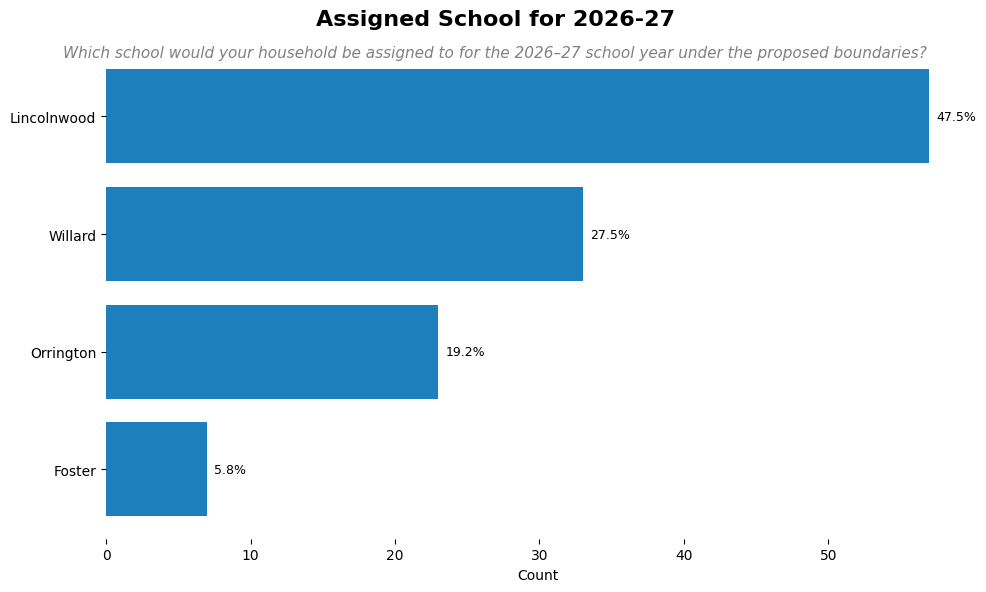

,preferred_school,count,percent
8,Lincolnwood or Willard,1,0.833333
9,No Preference,1,0.833333
7,Kingsley,2,1.666667
5,Most Kingsley Students,3,2.500000
6,Don't Know,3,2.500000
4,No Response,5,4.166667
3,Foster,6,5.000000
2,Orrington,16,13.333333
1,Willard,21,17.500000
0,Lincolnwood,62,51.666667


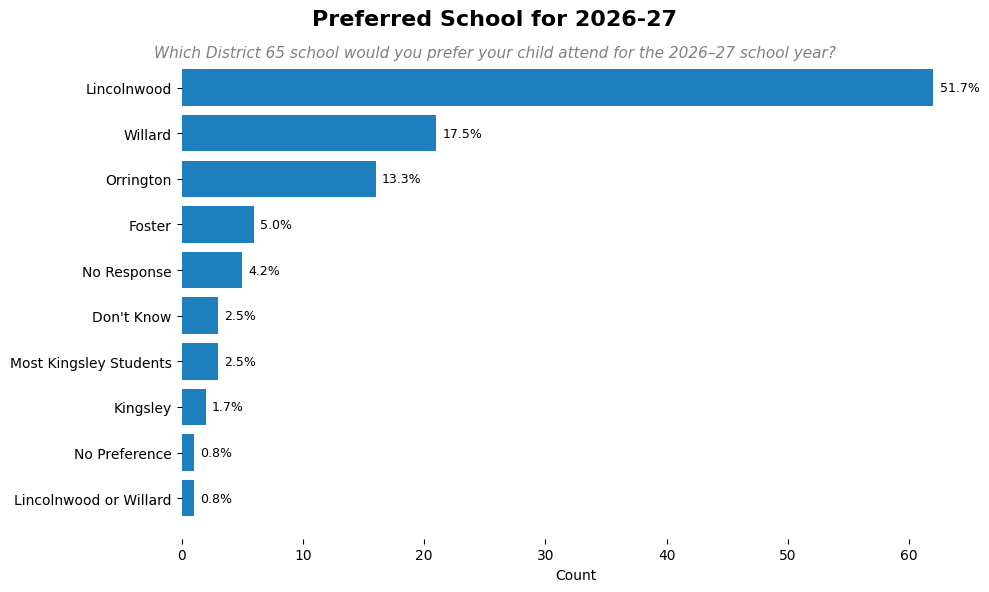

In [14]:
counts_pcts_plot(survey_df, 'assigned_school', 
                 title='Assigned School for 2026-27',
                 subtitle='Which school would your household be assigned to for the 2026–27 school year under the proposed boundaries?')

counts_pcts_plot(survey_df, 'preferred_school', 
                 title='Preferred School for 2026-27',
                 subtitle='Which District 65 school would you prefer your child attend for the 2026–27 school year?')

In [15]:
display(counts_pcts(df=survey_df, column_name='assigned_same_preferred'))
display(counts_pcts(df=survey_df, column_name='assigned_to_preferred'))

,assigned_same_preferred,count,percent
0,1,83,69.166667
1,0,37,30.833333


,assigned_to_preferred,count,percent
0,Lincolnwood - Lincolnwood,48,40.000000
1,Willard - Willard,20,16.666667
2,Orrington - Orrington,12,10.000000
3,Willard - Lincolnwood,7,5.833333
4,Orrington - Lincolnwood,5,4.166667
5,Willard - No Response,3,2.500000
6,Lincolnwood - Orrington,3,2.500000
7,Lincolnwood - Foster,3,2.500000
8,Foster - Foster,3,2.500000
9,Orrington - Most Kingsley Students,2,1.666667


In [16]:
# create sankey diagram
# count flows from assigned to preferred school
sankey_df = survey_df.groupby(['assigned_school', 'preferred_school']).size().reset_index(name='count')

# create node list (all unique schools)
nodes = list(set(sankey_df['assigned_school'].unique()) | set(sankey_df['preferred_school'].unique()))
nodes = sorted([n for n in nodes if pd.notna(n)])

# create node indices
node_dict = {node: idx for idx, node in enumerate(nodes)}

# map to indices
sankey_df['source_idx'] = sankey_df['assigned_school'].map(node_dict)
sankey_df['target_idx'] = sankey_df['preferred_school'].map(node_dict)

# node colors
# node_colors_list = [d65_dark_blue, d65_rust,d65_green,d65_light_gray]
# node_colors = [d65_dark_gray, 
#                d65_rust, d65_rust, d65_dark_gray, 
#                d65_dark_blue, d65_dark_blue, d65_dark_gray, d65_dark_gray, d65_dark_gray, d65_dark_gray,
#                d65_green, d65_green, 
#                d65_golden_yellow, d65_golden_yellow]


# calculate total count for each node
node_totals = {}
for idx in range(len(nodes)):
    # sum all flows through this node
    total = sankey_df[(sankey_df['source_idx'] == idx) | (sankey_df['target_idx'] == idx)]['count'].sum()
    node_totals[idx] = total

# create node labels with counts
node_labels = [f"{nodes[i]}<br>({node_totals[i]})" for i in range(len(nodes))]

# create node colors based on school
node_color_map = {'Lincolnwood': d65_dark_blue,
                  'Willard': d65_golden_yellow,
                  'Orrington': d65_green,
                  'Foster': d65_rust,
                 }

node_colors = []
for node in node_labels:
    color_assigned = False

    if "Lincolnwood or Willard" in node:
        node_colors.append(d65_dark_gray)
        color_assigned = True

    if not color_assigned:
        for key, value in node_color_map.items():
            if key in node:
                # print(f"Node: {node} contains key: {key}, assigning color: {value}")
                node_colors.append(value)
                color_assigned = True
                break

        if not color_assigned:
            # print(f"Node: {node} assigning default color: {d65_dark_gray}")
            node_colors.append(d65_dark_gray)

d65_light_gray_transparent = 'rgba(220, 220, 220, 0.4)'

# create sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=node_labels,
        color=node_colors,
        # x=[0.1 if node in assigned_schools else 0.9 for node in nodes],
        # y=[i / len(nodes) for i in range(len(nodes))]
    ),
    link=dict(
        source=sankey_df['source_idx'],
        target=sankey_df['target_idx'],
        value=sankey_df['count'],
        color=d65_light_gray_transparent
    )
)])

fig.add_annotation(x=0.05, y=1.05, text='<b>Assigned</b>', showarrow=False, font=dict(size=14))
fig.add_annotation(x=0.95, y=1.05, text='<b>Preferred</b>', showarrow=False, font=dict(size=14))


fig.update_layout(
    title='Assigned School Compared to Preferred School',
    font=dict(size=12),
    height=600,
    width=1000
)

fig.show()

### Important boundary factors

,label,count,percent
0,Diversity of student body,1,0.833333
3,Low student/teacher ratio,1,0.833333
5,Students not placed at a school that may close,3,2.500000
1,Even distribution of students across schools,13,10.833333
2,Flexibility for families to choose the school that works best for them,50,41.666667
4,Maximizing the number of Kingsley students who remain together,56,46.666667
6,"Walkability, safety, and ease of access to school",90,75.000000


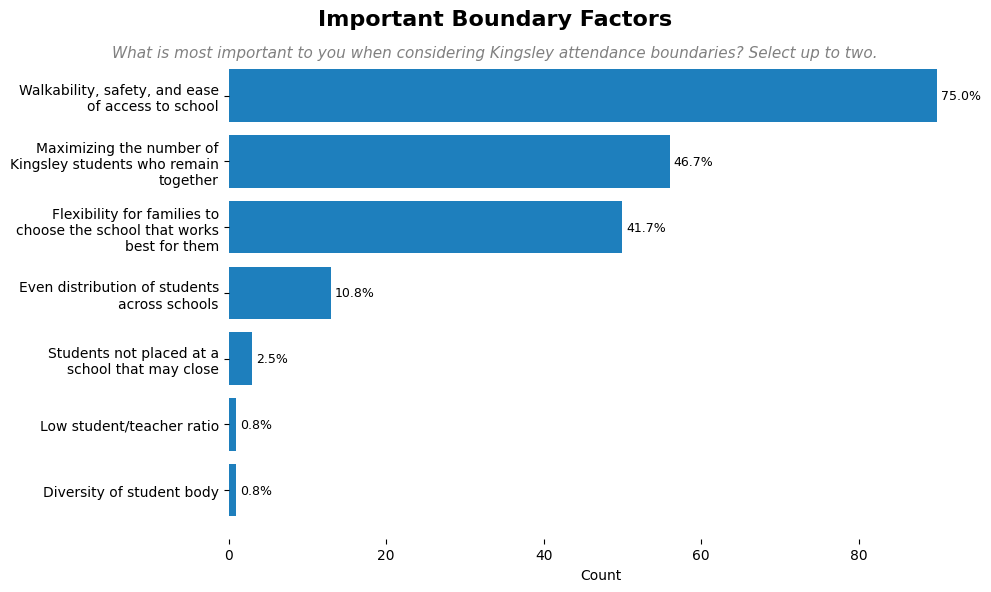

In [17]:
multi_select_chart(survey_df, 'important_boundary_factors',
                   title='Important Boundary Factors',
                   subtitle='What is most important to you when considering Kingsley attendance boundaries? Select up to two.')


In [18]:
display(counts_pcts(df=survey_df, column_name='ibf_stay_together'))

,ibf_stay_together,count,percent
0,1,90,75.0
1,0,30,25.0


### Walkability + community

,support_walkability_community_continuity,count,percent,category
3,1.0,4,3.389831,Very Opposed
4,2.0,4,3.389831,Opposed
2,3.0,19,16.101695,Neutral
1,4.0,28,23.728814,Supportive
0,5.0,63,53.389831,Very Supportive


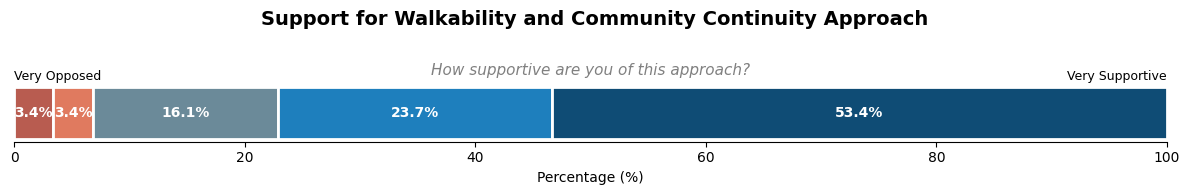

In [19]:
order_map = {1: 'Very Opposed',
             2: 'Opposed',
             3: 'Neutral',
             4: 'Supportive',
             5: 'Very Supportive',
             np.nan: 'No Response'}

likert_stacked_bar(survey_df, 'support_walkability_community_continuity', 
                  order_map=order_map,
                  title='Support for Walkability and Community Continuity Approach',
                  subtitle='How supportive are you of this approach?')

,preferred_school_community_continuity,count,percent
4,Foster,6,5.000000
3,Orrington,8,6.666667
2,No Response,9,7.500000
1,Willard,15,12.500000
0,Lincolnwood,82,68.333333


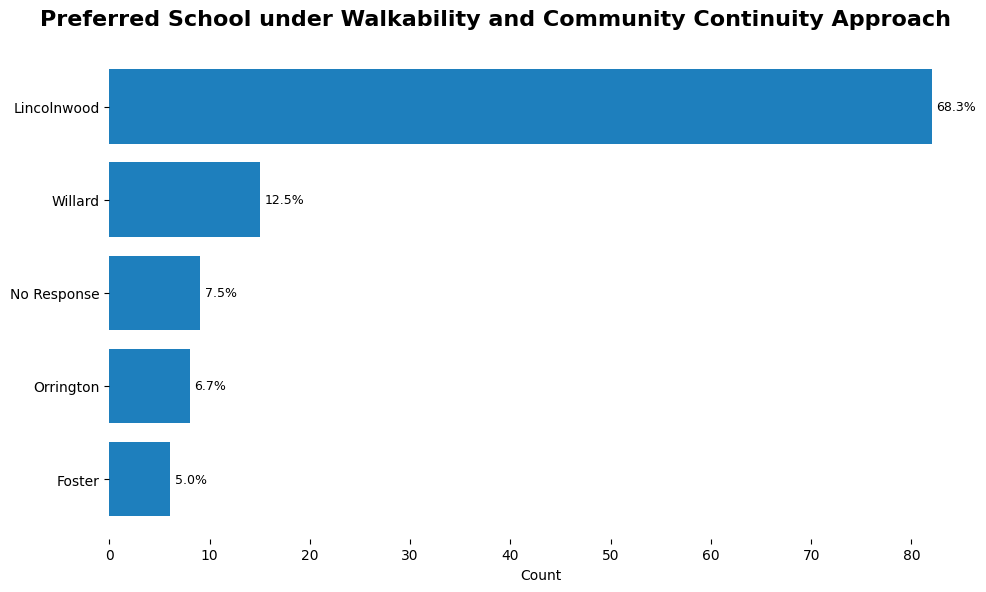

In [20]:
# counts_pcts_plot(survey_df, 'support_walkability_community_continuity',
#                  title='Support for Walkability and Community Continuity Approach')

counts_pcts_plot(survey_df, 'preferred_school_community_continuity',
                 title='Preferred School under Walkability and Community Continuity Approach')

### Guaranteed placement & permissive transfer

,preferred_school_guaranteed_placement,count,percent
5,No Response,1,0.833333
4,Foster,5,4.166667
3,Willard,10,8.333333
2,Orrington,11,9.166667
1,No preference / unsure,24,20.000000
0,Lincolnwood,69,57.500000


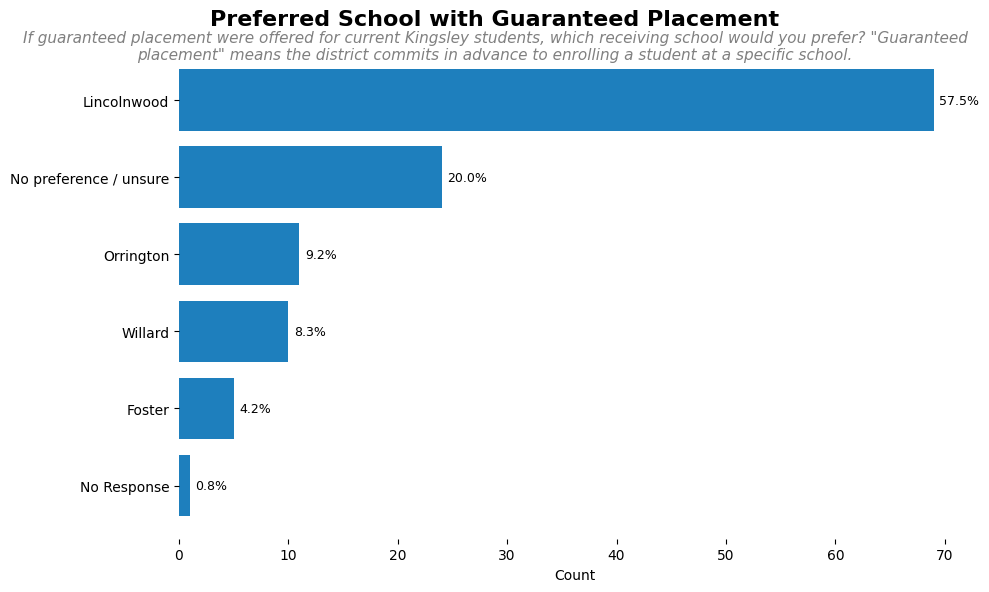

,request_permissive_transfer,count,percent
3,No Response,3,2.500000
2,Yes,16,13.333333
1,Not sure,41,34.166667
0,No,60,50.000000


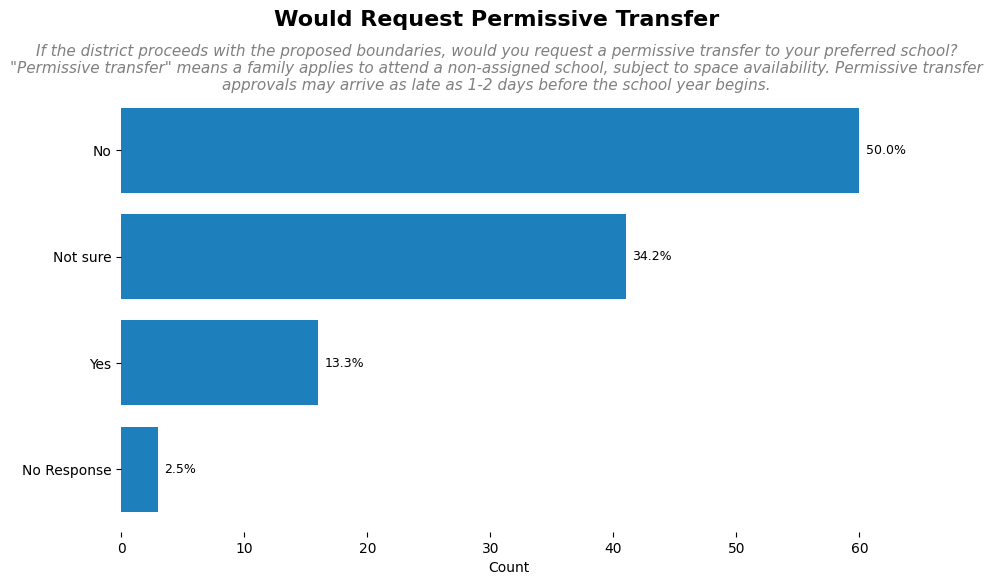

In [21]:
counts_pcts_plot(survey_df, 'preferred_school_guaranteed_placement',
                 title='Preferred School with Guaranteed Placement',
                 subtitle='If guaranteed placement were offered for current Kingsley students, which receiving school would you prefer? "Guaranteed placement" means the district commits in advance to enrolling a student at a specific school.'
                 )

counts_pcts_plot(survey_df, 'request_permissive_transfer',
                 title='Would Request Permissive Transfer',
                 subtitle='If the district proceeds with the proposed boundaries, would you request a permissive transfer to your preferred school?\n"Permissive transfer" means a family applies to attend a non-assigned school, subject to space availability. Permissive transfer approvals may arrive as late as 1-2 days before the school year begins.',
                 subt_y = 0.85,
                 subplot_adj_top=0.85
                 )

# Transition Support

,label,count,percent
1,All of these!,1,0.833333
7,No response,1,0.833333
9,Pen pal with a student at the new school during 2025–26,26,21.666667
0,504 plan / IEP transition meetings before the end of the 2025–26 school year,34,28.333333
11,Shadow days during the 2025–26 school year,34,28.333333
4,Continuity in before/after school programming,41,34.166667
10,Same-age buddy assigned to my child,49,40.833333
3,Classroom assignments that keep familiar peers together,73,60.833333
8,Parent opportunities to meet faculty and staff,79,65.833333
6,Kingsley teachers or staff transitioning to the new school,89,74.166667


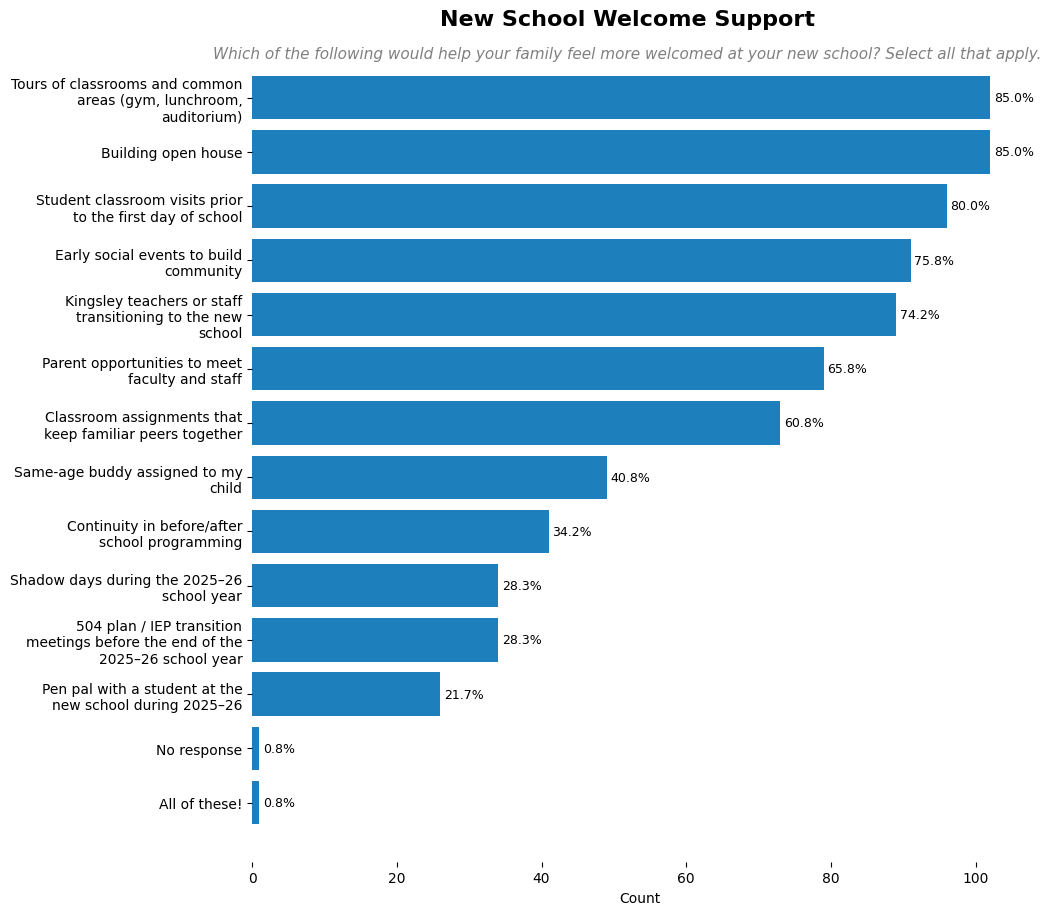

In [22]:
# select_multi_cols
multi_select_chart(survey_df, 'help_feel_welcomed',
                   title='New School Welcome Support',
                   subtitle='Which of the following would help your family feel more welcomed at your new school? Select all that apply.',
                   big_labels=True,
                   subt_y=0.93,
                   subplot_adj_top=0.95
                   )

# Intent to Stay

,likely_remain_district65,count,percent,category
2,1.0,8,6.837607,Not Likely
4,2.0,4,3.418803,Somewhat not likely
3,3.0,6,5.128205,Neutral
1,4.0,18,15.384615,Somewhat likely
0,5.0,81,69.230769,Very Likely


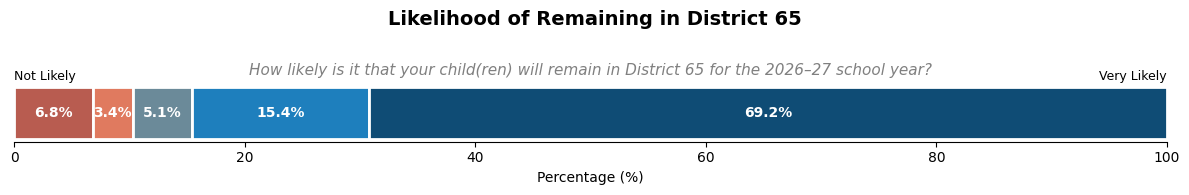

In [23]:
# likely_remain_district65
order_map = {1: 'Not Likely',
             2: 'Somewhat not likely',
             3: 'Neutral',
             4: 'Somewhat likely',
             5: 'Very Likely',
             np.nan: 'No Response'}

likert_stacked_bar(survey_df, 'likely_remain_district65', 
                  order_map=order_map,
                  title='Likelihood of Remaining in District 65',
                  subtitle='How likely is it that your child(ren) will remain in District 65 for the 2026–27 school year?')

,where_attend_not_district65,count,percent
7,Preschool,1,0.833333
8,Its a serious consideration. The school district has shown nothing but misdirection and duplicity.,1,0.833333
9,Unknown,1,0.833333
10,Homeschool,1,0.833333
5,Chicago Public Schools,2,1.666667
6,Don't Know,2,1.666667
3,Stay in District 65,3,2.500000
4,Private school outside Evanston,3,2.500000
2,Public school outside Evanston due to a move,8,6.666667
1,Private school in Evanston,31,25.833333


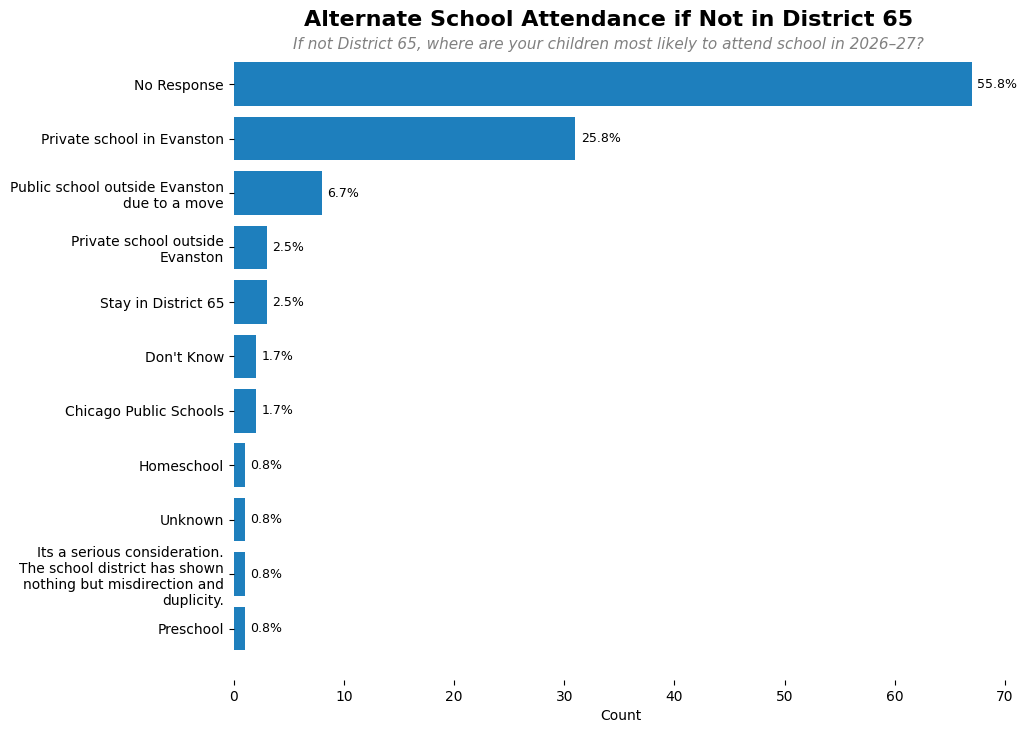

In [24]:
# where_attend_not_district65
counts_pcts_plot(survey_df, 'where_attend_not_district65', 
                 title='Alternate School Attendance if Not in District 65',
                 subtitle='If not District 65, where are your children most likely to attend school in 2026–27?',
                 big_labels=True,
                 subt_y=0.93,
                 subplot_adj_top=0.95)


,where_attend_not_district65,count,percent
3,Preschool,1,8.333333
4,No Response,1,8.333333
2,Private school outside Evanston,2,16.666667
1,Public school outside Evanston due to a move,3,25.000000
0,Private school in Evanston,5,41.666667


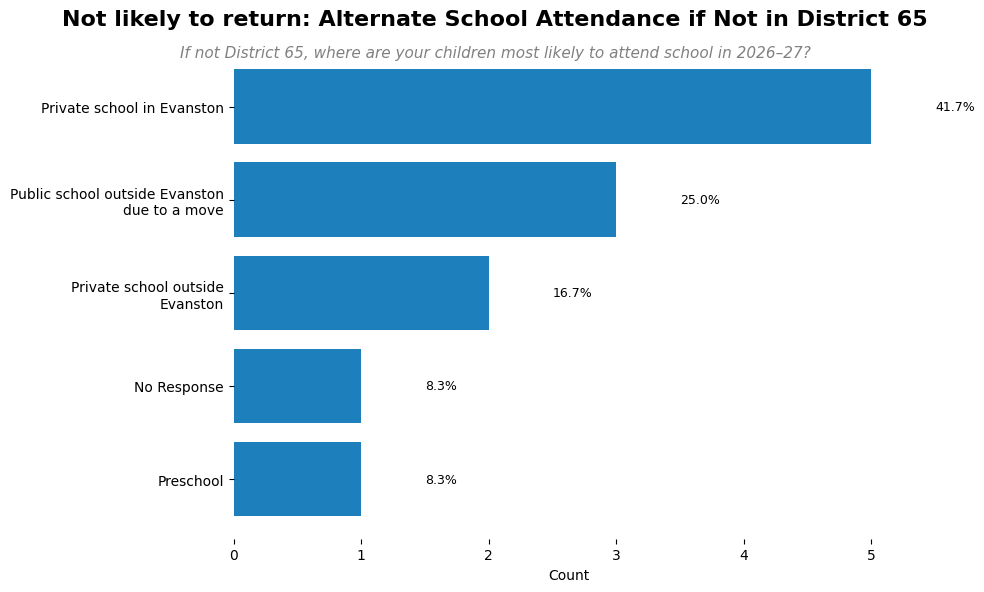

In [25]:
counts_pcts_plot(survey_df[survey_df['likely_remain_district65'].isin([1,2])], 
                 'where_attend_not_district65', 
                 title='Not likely to return: Alternate School Attendance if Not in District 65',
                 subtitle='If not District 65, where are your children most likely to attend school in 2026–27?',
                 big_labels=True)

,label,count,percent
9,Lack of stability in D65,1,0.833333
18,"We're all in this together, we're not leaving the district.",1,0.833333
5,"Dissatisfaction with specific board members Mya Wilkins, Sergio Hernandez, Dr. Andrew Wymer",1,0.833333
19,"None, again, it's no big deal. chill. it's a different building. deal with it.",1,0.833333
1,Class size,1,0.833333
4,Dissatisfaction with Superintendent Dr. Angel Turner,2,1.666667
16,No advanced curriculum,2,1.666667
17,Too much technology,2,1.666667
0,A planned move unrelated to district 65,4,3.333333
13,Logistical challenges getting to/from my assigned school,16,13.333333


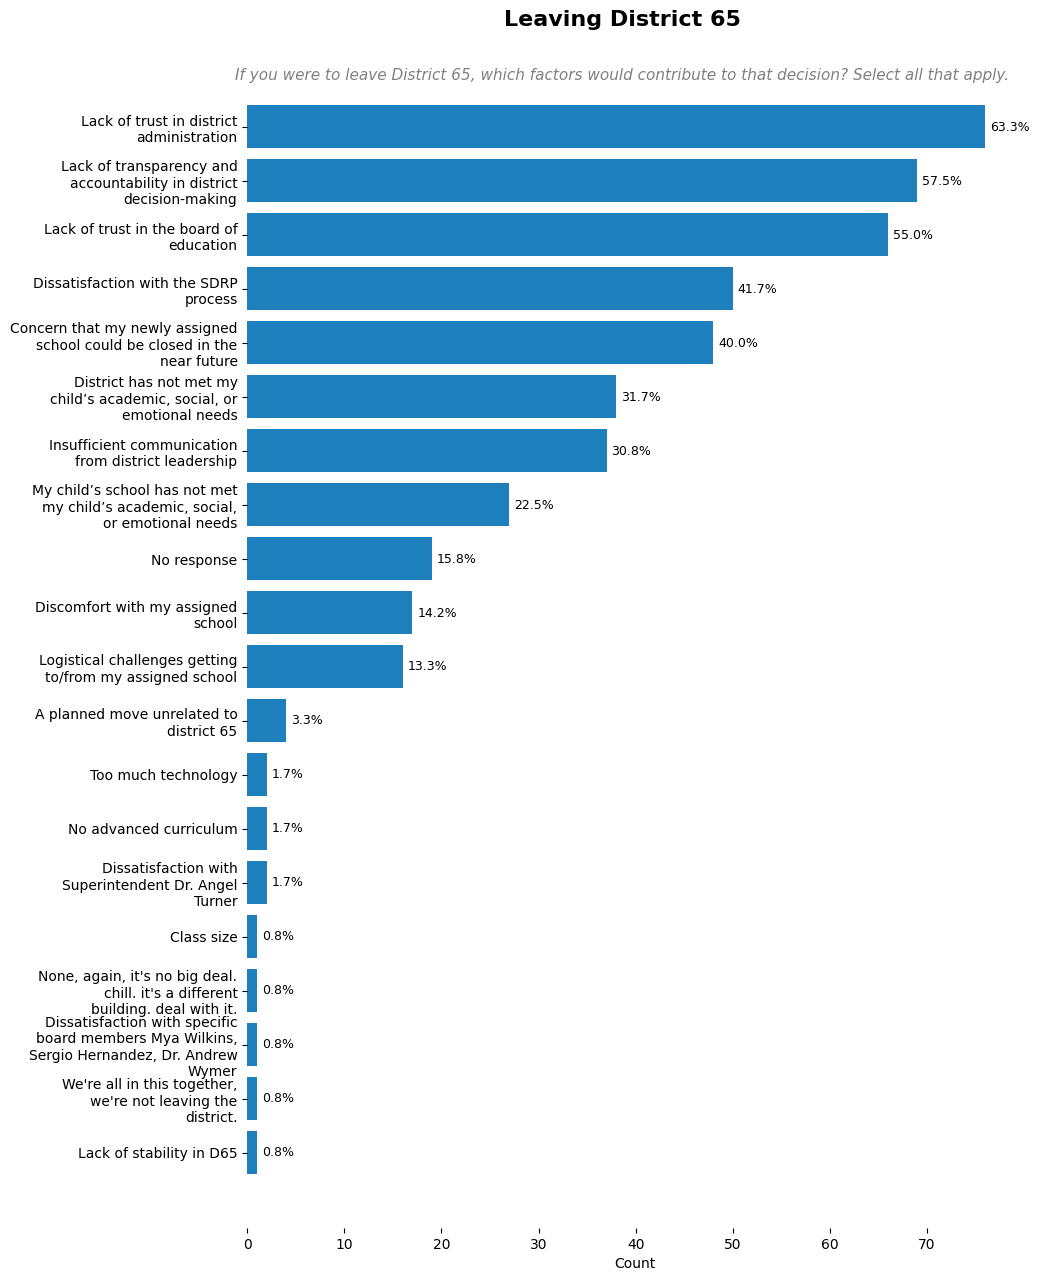

In [26]:
multi_select_chart(survey_df, 'factors_contribute_leave_district65',
                   title='Leaving District 65',
                   subtitle='If you were to leave District 65, which factors would contribute to that decision? Select all that apply.',
                   big_labels=True,
                   subt_y=0.93,
                   subplot_adj_top=0.95)

# Demographics

,parent_type,count,percent
3,A resident within Kingsley boundaries with adult children or no children,1,0.833333
4,No Response,1,0.833333
2,A resident within Kingsley boundaries with children not yet school-aged,5,4.166667
1,A parent of a Kingsley alum,6,5.000000
0,A current Kingsley parent,107,89.166667


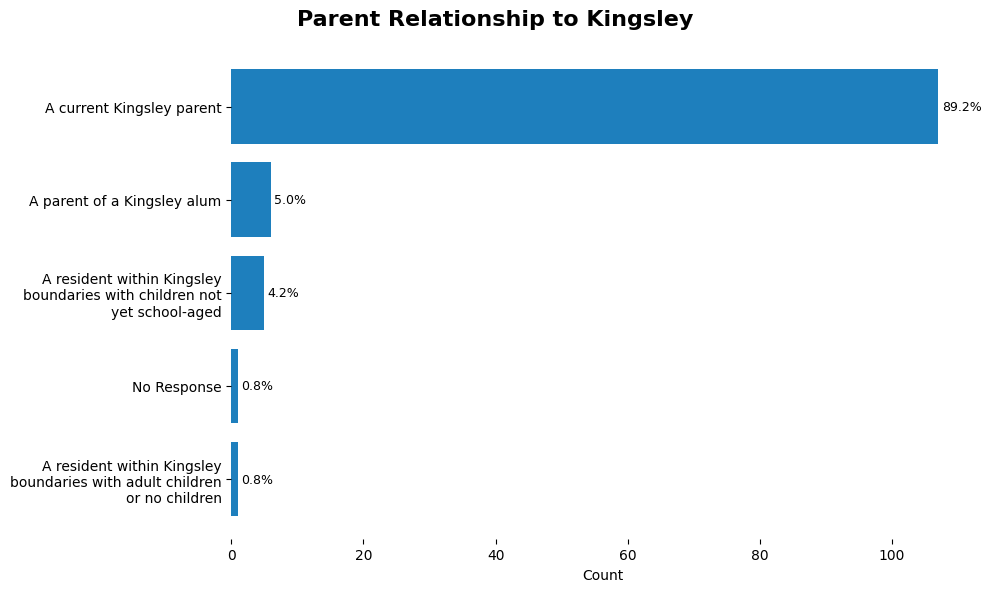

In [27]:
counts_pcts_plot(survey_df, 'parent_type', 
                 title='Parent Relationship to Kingsley',)

,label,count,percent
6,I have adult children or no children,1,0.833333
4,5,12,10.000000
8,Pre-k or younger (not yet at Kingsley),16,13.333333
2,3,25,20.833333
5,6+ / attended Kingsley in the past,25,20.833333
7,K,29,24.166667
1,2,31,25.833333
0,1,32,26.666667
3,4,40,33.333333


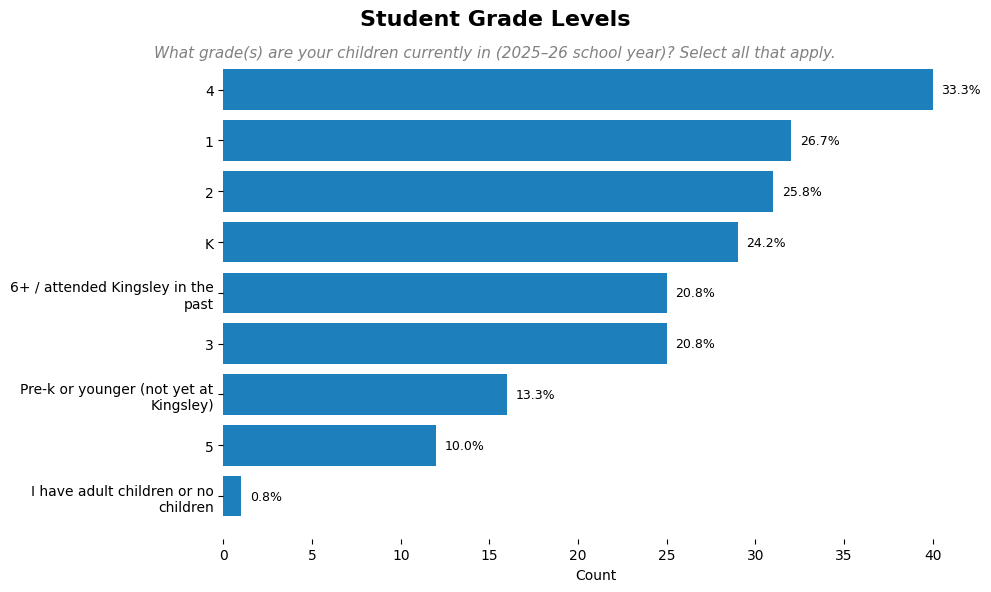

In [28]:
multi_select_chart(survey_df, 'children_grades',
                   title='Student Grade Levels',
                   subtitle='What grade(s) are your children currently in (2025–26 school year)? Select all that apply.')

# Open ended responses - AI analysis

## What traditions, programs, or aspects of Kingsley’s culture do you hope will continue in your child’s new school?

Top 10 Traditions/Programs Parents Hope Will Continue
* Fall Fest (approximately 20+ mentions)
* Talent Show (approximately 8-10 mentions)
* Spring Fest/Spring Fling/Spring Carnival (approximately 8-9 mentions)
* Fun Run/Spirit Run/Race Day (approximately 7-8 mentions)
* Small/Tall Ball (approximately 6-7 mentions)
* Haunted Hallway/Halloween Events (approximately 6 mentions)
* Field Day/Track Day (approximately 4-5 mentions)
* Community/Sense of Belonging (approximately 4-5 mentions)
* Teachers/Staff (approximately 4 mentions)
* Book Closet (approximately 3 mentions)

Honorable mentions: SACC/Right at School childcare programs (3 mentions), Music programs/concerts (3 mentions), Penny Wars (2 mentions), 5th grade traditions (2 mentions), and Brickology (1 mention).

The overwhelming theme is community-building events that bring families together, with Fall Fest being the clear standout.


## What support will your child or family need most during this transition?

Top 10 Support Needs During Transition
* Opportunities to visit/tour the new school in advance (approximately 12-15 mentions)
* Community building/social events before school starts (approximately 10-12 mentions)
* Timely and transparent communication from the district (approximately 8-10 mentions)
* Maintaining friendships/keeping Kingsley peers together (approximately 6-7 mentions)
* Meeting teachers and staff early (approximately 5-6 mentions)
* IEP/504 plan transitions and support (approximately 4-5 mentions)
* Assurance that Lincolnwood won't also close (approximately 3 mentions)
* Information about logistics (approximately 3-4 mentions)
* Emotional support for children (approximately 2-3 mentions)
* Empathy and understanding from the district (approximately 2-3 mentions)

Key insight: Parents overwhelmingly want proactive, early engagement with the new school—physical visits, social connections, and clear information—rather than waiting until the school year starts.

## What are you most worried about regarding your school transition?

Top 10 Worries About School Transition
* Splitting up friend groups/loss of friendships (approximately 18-20 mentions)
* Fear that Lincolnwood will also close (another transition in 2027-28) (approximately 10-12 mentions)
* Social integration/being accepted in established communities (approximately 8-10 mentions)
* Loss of familiar/trusted teachers and staff (approximately 6-7 mentions)
* Support for children with IEPs/504 plans/special needs (approximately 5-6 mentions)
* Transportation and walkability concerns (approximately 4-5 mentions)
* Lack of timely/transparent communication and planning (approximately 4-5 mentions)
* Academic disruption and maintaining educational progress (approximately 3-4 mentions)
* Emotional impact on children/difficulty of transition (approximately 3-4 mentions)
* Overcrowding and inadequate facilities/resources at new schools (approximately 2-3 mentions)

Notable additional concerns: Loss of diversity at new schools (2 mentions), impact on Kingsley faculty/staff losing jobs (2 mentions), children being spread across too many different schools rather than kept together as a cohort.

Key insight: The dominant theme is relationship disruption—losing friends, familiar staff, and community connections that provide stability and support for children.
